qmax = 947.37 STB/day


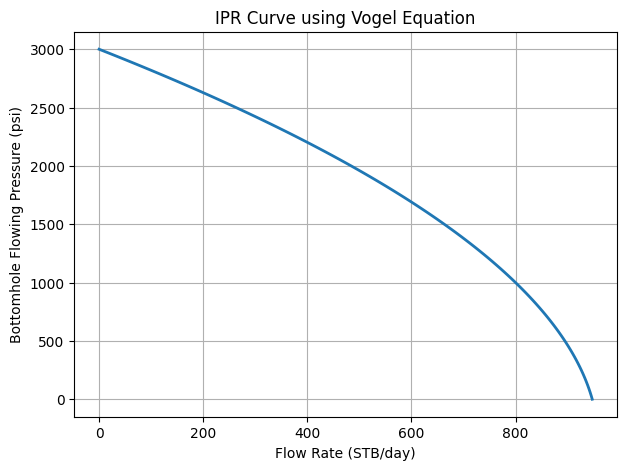

In [29]:
# STEP-1: IPR USING VOGEL METHOD

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# GIVEN DATA
# -----------------------------
Pr = 3000          # Reservoir pressure (psi)
Pwf_test = 1000    # Test flowing pressure (psi)
q_test = 800       # Test production rate (STB/day)

# -----------------------------
# CALCULATE qmax USING VOGEL
# -----------------------------
qmax = q_test / (1 - 0.2*(Pwf_test/Pr) - 0.8*(Pwf_test/Pr)**2)

print("qmax =", round(qmax,2), "STB/day")

# -----------------------------
# GENERATE IPR CURVE
# -----------------------------
Pwf = np.linspace(0, Pr, 100)

q = qmax * (1 - 0.2*(Pwf/Pr) - 0.8*(Pwf/Pr)**2)

# -----------------------------
# PLOT GRAPH
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(q, Pwf, linewidth=2)

plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("IPR Curve using Vogel Equation")

plt.grid(True)

plt.show()

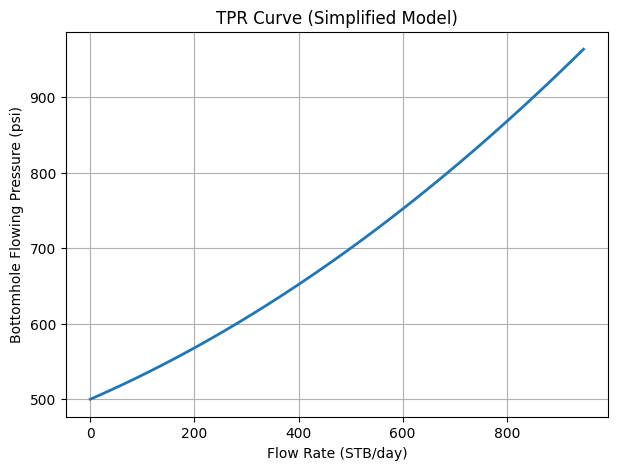

In [36]:
# STEP-2: TPR MODEL (SIMPLIFIED)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# GIVEN DATA
# -----------------------------
Pwh = 500        # Wellhead pressure (psi)

a = 0.30         # Hydrostatic coefficient
b = 0.0002       # Friction coefficient

# -----------------------------
# GENERATE FLOW RATE RANGE
# -----------------------------
q = np.linspace(0, qmax, 500)

# -----------------------------
# CALCULATE Pwf USING TPR
# -----------------------------
Pwf_tpr = Pwh + a*q + b*(q**2)

# -----------------------------
# PLOT GRAPH
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(q, Pwf_tpr, linewidth=2)

plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("TPR Curve (Simplified Model)")

plt.grid(True)
plt.show()

Operating Rate = 860.04 STB/day
Operating Pwf = 910.86 psi


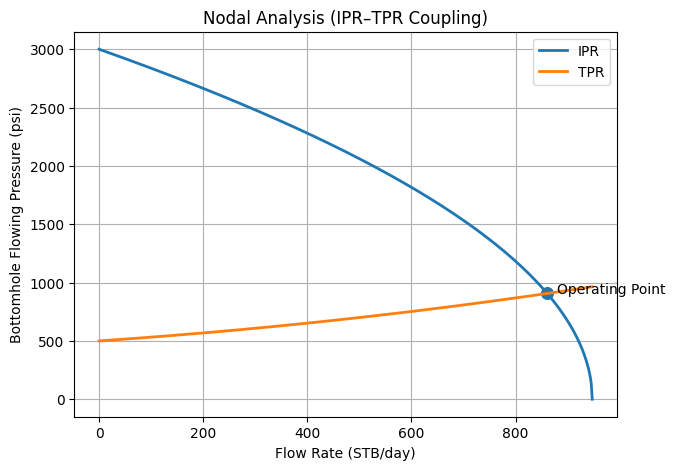

In [37]:
# STEP-3: FULL NODAL ANALYSIS

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# IPR DATA (FROM STEP-1)
# -----------------------------
Pr = 3000
Pwf_test = 1000
q_test = 800

qmax = q_test / (1 - 0.2*(Pwf_test/Pr) - 0.8*(Pwf_test/Pr)**2)

# -----------------------------
# TPR DATA (FROM STEP-2)
# -----------------------------
Pwh = 500
a = 0.30
b = 0.0002

# -----------------------------
# GENERATE FLOW RANGE
# -----------------------------
q = np.linspace(0, qmax, 500)

# -----------------------------
# CALCULATE IPR + TPR
# -----------------------------
Pwf_ipr = Pr * (1 - (q/qmax))**0.5  # alt Vogel form for plotting smooth curve
Pwf_tpr = Pwh + a*q + b*q**2

# -----------------------------
# FIND OPERATING POINT
# -----------------------------
diff = abs(Pwf_ipr - Pwf_tpr)
index = np.argmin(diff)

q_op = q[index]
Pwf_op = Pwf_ipr[index]

print("Operating Rate =", round(q_op,2), "STB/day")
print("Operating Pwf =", round(Pwf_op,2), "psi")

# -----------------------------
# PLOT NODAL GRAPH
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(q, Pwf_ipr, label="IPR", linewidth=2)
plt.plot(q, Pwf_tpr, label="TPR", linewidth=2)

plt.scatter(q_op, Pwf_op, s=70)
plt.text(q_op+20, Pwf_op, "Operating Point")

plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("Nodal Analysis (IPR–TPR Coupling)")

plt.legend()
plt.grid(True)
plt.show()

----- Tubing Size Effect -----
Small Tubing → Operating Rate = 841.1 STB/day
Medium Tubing → Operating Rate = 860.0 STB/day
Large Tubing → Operating Rate = 873.3 STB/day

 OPTIMAL TUBING SELECTION
Best Tubing = Large Tubing
Maximum Production = 873.3 STB/day
Production Improvement = 3.84 %


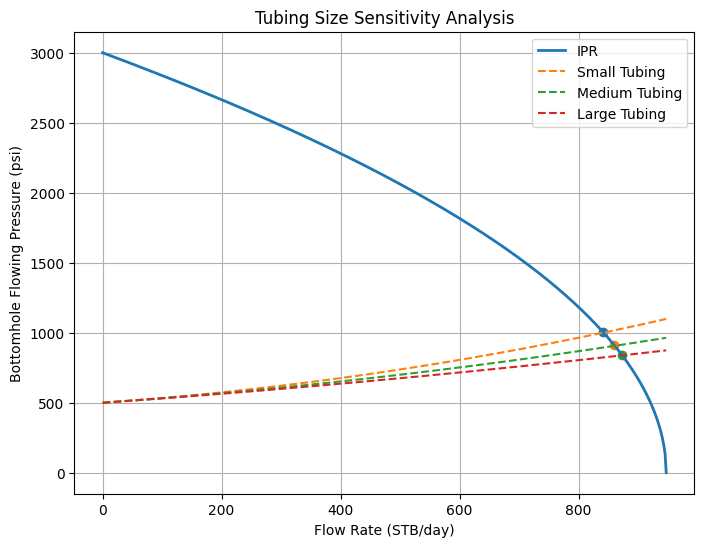

In [60]:
# ============================================
# STEP-4A: TUBING SIZE SENSITIVITY (UPGRADED)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# IPR DATA
# -----------------------------
Pr = 3000
Pwf_test = 1000
q_test = 800

qmax = q_test / (1 - 0.2*(Pwf_test/Pr) - 0.8*(Pwf_test/Pr)**2)

q = np.linspace(0, qmax, 500)
Pwf_ipr = Pr * (1 - (q/qmax))**0.5

# -----------------------------
# TPR PARAMETERS
# -----------------------------
Pwh = 500
a = 0.30

b_values = [0.00035, 0.0002, 0.0001]
labels = ["Small Tubing", "Medium Tubing", "Large Tubing"]

plt.figure(figsize=(8,6))
plt.plot(q, Pwf_ipr, label="IPR", linewidth=2)

print("----- Tubing Size Effect -----")

# ADD THIS (decision tracking)
rates = {}

for b, label in zip(b_values, labels):

    Pwf_tpr = Pwh + a*q + b*q**2

    diff = np.abs(Pwf_ipr - Pwf_tpr)
    idx = np.argmin(diff)

    q_op = q[idx]
    Pwf_op = Pwf_ipr[idx]

    rates[label] = q_op  # store results

    print(f"{label} → Operating Rate = {round(q_op,1)} STB/day")

    plt.plot(q, Pwf_tpr, linestyle="--", label=label)
    plt.scatter(q_op, Pwf_op)

# DECISION LOGIC
best_tubing = max(rates, key=rates.get)
best_rate = rates[best_tubing]

print("\n OPTIMAL TUBING SELECTION")
print(f"Best Tubing = {best_tubing}")
print(f"Maximum Production = {round(best_rate,1)} STB/day")

#  PERFORMANCE COMPARISON
min_rate = min(rates.values())
improvement = ((best_rate - min_rate) / min_rate) * 100

print(f"Production Improvement = {round(improvement,2)} %")

# Plot settings
plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("Tubing Size Sensitivity Analysis")

plt.legend()
plt.grid(True)
plt.show()

----- Wellhead Pressure Effect -----
WHP = 300 psi → Operating Rate = 892.3 STB/day
WHP = 500 psi → Operating Rate = 860.0 STB/day
WHP = 700 psi → Operating Rate = 824.0 STB/day

 OPTIMAL WELLHEAD PRESSURE
Best WHP = 300 psi
Maximum Production = 892.3 STB/day
Production Improvement = 8.29 %


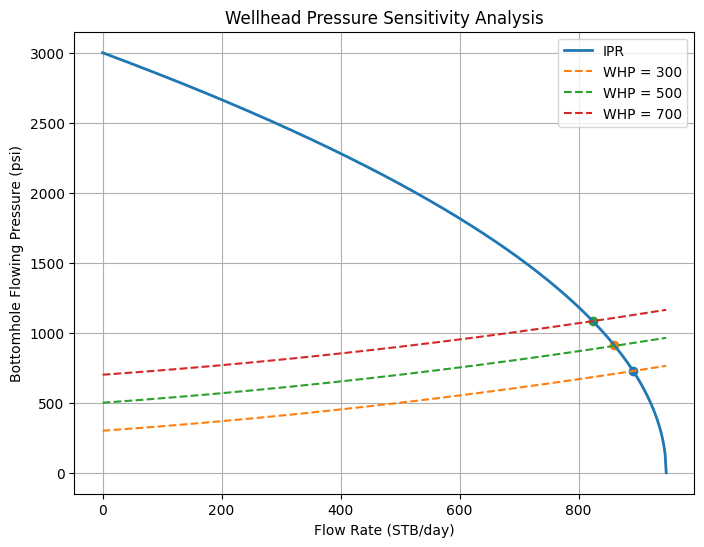

In [61]:
# ============================================
# STEP-4B: WELLHEAD PRESSURE (UPGRADED)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# IPR DATA
# -----------------------------
Pr = 3000
Pwf_test = 1000
q_test = 800

qmax = q_test / (1 - 0.2*(Pwf_test/Pr) - 0.8*(Pwf_test/Pr)**2)

q = np.linspace(0, qmax, 500)
Pwf_ipr = Pr * (1 - (q/qmax))**0.5

# -----------------------------
# TPR PARAMETERS
# -----------------------------
a = 0.30
b = 0.0002

Pwh_values = [300, 500, 700]

plt.figure(figsize=(8,6))
plt.plot(q, Pwf_ipr, label="IPR", linewidth=2)

print("----- Wellhead Pressure Effect -----")

#  ADD THIS
rates = {}

for Pwh in Pwh_values:

    Pwf_tpr = Pwh + a*q + b*q**2

    diff = np.abs(Pwf_ipr - Pwf_tpr)
    idx = np.argmin(diff)

    q_op = q[idx]
    Pwf_op = Pwf_ipr[idx]

    rates[Pwh] = q_op  # store result

    print(f"WHP = {Pwh} psi → Operating Rate = {round(q_op,1)} STB/day")

    plt.plot(q, Pwf_tpr, linestyle="--", label=f"WHP = {Pwh}")
    plt.scatter(q_op, Pwf_op)

#  DECISION LOGIC
best_whp = max(rates, key=rates.get)
best_rate = rates[best_whp]

print("\n OPTIMAL WELLHEAD PRESSURE")
print(f"Best WHP = {best_whp} psi")
print(f"Maximum Production = {round(best_rate,1)} STB/day")

# PERFORMANCE IMPACT
max_rate = max(rates.values())
min_rate = min(rates.values())

improvement = ((max_rate - min_rate) / min_rate) * 100

print(f"Production Improvement = {round(improvement,2)} %")

# Plot settings
plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("Wellhead Pressure Sensitivity Analysis")

plt.legend()
plt.grid(True)
plt.show()

----- Reservoir Depletion -----
Pr = 3000 psi → Rate = 860.0 STB/day
Pr = 2500 psi → Rate = 705.6 STB/day
Pr = 2000 psi → Rate = 548.0 STB/day


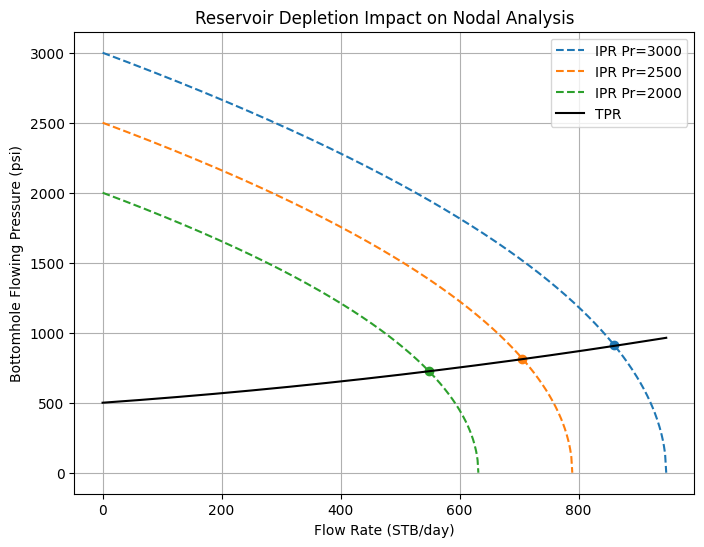

In [62]:
# ============================================
# STEP-5A: RESERVOIR DEPLETION (FINAL REALISTIC)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Initial reservoir data
Pr_initial = 3000
Pwf_test = 1000
q_test = 800

# Initial qmax
qmax_initial = q_test / (1 - 0.2*(Pwf_test/Pr_initial) - 0.8*(Pwf_test/Pr_initial)**2)

# TPR constants
Pwh = 500
a = 0.30
b = 0.0002

# Reservoir pressures
Pr_values = [3000, 2500, 2000]

plt.figure(figsize=(8,6))

print("----- Reservoir Depletion -----")

for Pr in Pr_values:

    # Scale qmax with pressure
    qmax = qmax_initial * (Pr / Pr_initial)

    q = np.linspace(0, qmax, 500)

    # IPR
    Pwf_ipr = Pr * (1 - (q/qmax))**0.5

    # TPR
    Pwf_tpr = Pwh + a*q + b*q**2

    # Operating point
    diff = np.abs(Pwf_ipr - Pwf_tpr)
    idx = np.argmin(diff)

    q_op = q[idx]
    Pwf_op = Pwf_ipr[idx]

    print(f"Pr = {Pr} psi → Rate = {round(q_op,1)} STB/day")

    plt.plot(q, Pwf_ipr, linestyle="--", label=f"IPR Pr={Pr}")
    plt.scatter(q_op, Pwf_op)

# Plot TPR
q_plot = np.linspace(0, qmax_initial, 500)
Pwf_tpr = Pwh + a*q_plot + b*q_plot**2
plt.plot(q_plot, Pwf_tpr, 'k', label="TPR")

plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("Reservoir Depletion Impact on Nodal Analysis")

plt.legend()
plt.grid(True)

plt.show()

----- Gas Lift Effect -----
No Gas Lift → Operating Rate = 860.0 STB/day
With Gas Lift → Operating Rate = 875.2 STB/day

 GAS LIFT DECISION
Recommendation: Apply Gas Lift
Production Increase = 1.77 %
Marginal Benefit – Evaluate Cost


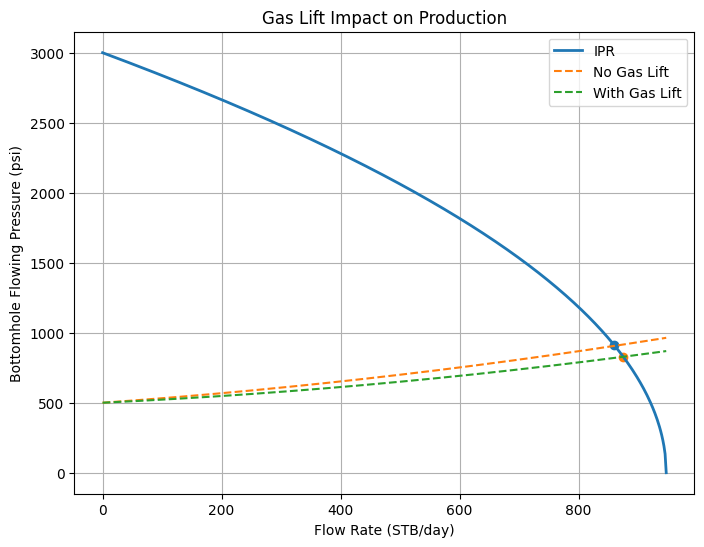

In [66]:
# ============================================
# STEP-5B: GAS LIFT (UPGRADED WITH DECISION)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# IPR DATA
# -----------------------------
Pr = 3000
Pwf_test = 1000
q_test = 800

qmax = q_test / (1 - 0.2*(Pwf_test/Pr) - 0.8*(Pwf_test/Pr)**2)

q = np.linspace(0, qmax, 500)
Pwf_ipr = Pr * (1 - (q/qmax))**0.5

# -----------------------------
# TPR PARAMETERS
# -----------------------------
Pwh = 500
b = 0.0002

a_values = [0.30, 0.20]
labels = ["No Gas Lift", "With Gas Lift"]

plt.figure(figsize=(8,6))
plt.plot(q, Pwf_ipr, label="IPR", linewidth=2)

print("----- Gas Lift Effect -----")

# STORE RESULTS
rates = {}

for a, label in zip(a_values, labels):

    Pwf_tpr = Pwh + a*q + b*q**2

    diff = np.abs(Pwf_ipr - Pwf_tpr)
    idx = np.argmin(diff)

    q_op = q[idx]
    Pwf_op = Pwf_ipr[idx]

    rates[label] = q_op

    print(f"{label} → Operating Rate = {round(q_op,1)} STB/day")

    plt.plot(q, Pwf_tpr, linestyle="--", label=label)
    plt.scatter(q_op, Pwf_op)

# DECISION LOGIC
rate_no = rates["No Gas Lift"]
rate_gl = rates["With Gas Lift"]

improvement = ((rate_gl - rate_no) / rate_no) * 100

print("\n GAS LIFT DECISION")

if rate_gl > rate_no:
    print("Recommendation: Apply Gas Lift")
    print(f"Production Increase = {round(improvement,2)} %")
else:
    print("Recommendation: Gas Lift not required")

# THRESHOLD (ADVANCED ENGINEERING LOGIC)
if improvement > 5:
    print("Strong Economic Justification")
else:
    print("Marginal Benefit – Evaluate Cost")

# Plot settings
plt.xlabel("Flow Rate (STB/day)")
plt.ylabel("Bottomhole Flowing Pressure (psi)")
plt.title("Gas Lift Impact on Production")

plt.legend()
plt.grid(True)
plt.show()